In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load from excel
db_main = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data.xlsx')
db_aanerud = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data-aanerud.xlsx')


In [75]:
db_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Linje          250 non-null    object        
 1   Vogn           214 non-null    object        
 2   Dato           250 non-null    datetime64[ns]
 3   Klokke         250 non-null    object        
 4   Fra            250 non-null    object        
 5   Til            250 non-null    object        
 6   Fullt?         250 non-null    object        
 7   Sjekket?       250 non-null    object        
 8   Sjekket etter  19 non-null     object        
 9   Merknad        78 non-null     object        
dtypes: datetime64[ns](1), object(9)
memory usage: 19.7+ KB


In [76]:
db_aanerud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Linje     44 non-null     object        
 1   Vogn      43 non-null     object        
 2   Dato      44 non-null     datetime64[ns]
 3   Klokke    44 non-null     object        
 4   Fra       44 non-null     object        
 5   Til       44 non-null     object        
 6   Fullt?    44 non-null     object        
 7   Sjekket?  44 non-null     object        
 8   Merknad   14 non-null     object        
dtypes: datetime64[ns](1), object(8)
memory usage: 3.2+ KB


In [77]:
db = pd.concat([db_main, db_aanerud], ignore_index=True)
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Linje          294 non-null    object        
 1   Vogn           257 non-null    object        
 2   Dato           294 non-null    datetime64[ns]
 3   Klokke         294 non-null    object        
 4   Fra            294 non-null    object        
 5   Til            294 non-null    object        
 6   Fullt?         294 non-null    object        
 7   Sjekket?       294 non-null    object        
 8   Sjekket etter  19 non-null     object        
 9   Merknad        92 non-null     object        
dtypes: datetime64[ns](1), object(9)
memory usage: 23.1+ KB


# Cleaning and engineering the features

In [78]:
# Convert all column names to lowercase
db.columns = db.columns.str.lower()

# Replace space with underscore in column names
db.columns = db.columns.str.replace(' ', '_')

# Remove special characters from column names
db.columns = db.columns.str.replace(r'[?]', '', regex=True)

In [79]:
# Date convert to discrete features
db['day'] = db['dato'].dt.day
db['month'] = db['dato'].dt.month
db['year'] = db['dato'].dt.year
db['weekday'] = db['dato'].dt.weekday
db['weekofyear'] = db['dato'].dt.isocalendar().week

# Remove the original date column
db = db.drop(columns=['dato'])

In [80]:
# Convert "klokke" to datetime
db['klokke'] = pd.to_datetime(db['klokke'], format='%H:%M:%S', errors='coerce')

# Convert departure time to discrete features
db['hour'] = db['klokke'].dt.hour
db['minute'] = db['klokke'].dt.minute
db['second'] = db['klokke'].dt.second

# Remove the original time column
db = db.drop(columns=['klokke'])

In [81]:
# lower all string values in the dataframe
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.lower()

# Spaces become non if end of string
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.strip()

# ja/nei -> ja and nei/ja -> ja in "sjekket" column
db['sjekket'] = db['sjekket'].replace({'ja/nei': 'ja', 'nei/ja': 'ja'})

In [82]:

db.head()

,linje,vogn,fra,til,fullt,sjekket,sjekket_etter,merknad,day,month,year,weekday,weekofyear,hour,minute,second
0,l12,fremst,eidsvoll,oslo lufthavn,nei,nei,NaN,NaN,25,9,2022,6,38,11,30,0
1,r10,bakerst,oslo lufthavn,eidsvoll,ja,ja,NaN,NaN,25,9,2022,6,38,21,59,0
2,l12,fremst,eidsvoll,nationaltheatret,ja,nei,NaN,NaN,26,9,2022,0,39,9,30,0
3,l12,bakerst,nationaltheatret,eidsvoll,ja,nei,NaN,NaN,26,9,2022,0,39,13,48,0
4,r11,fremst,eidsvoll,oslo lufthavn,nei,ja,NaN,sjekket med en gang,27,9,2022,1,39,6,0,0


### Convert "sjekket etter" to something useful

In [83]:
# TODO implement
# Remove for now
db = db.drop(columns=['sjekket_etter'])

In [84]:
# Converting all strings to numumeric values
for col in db.select_dtypes(include=['object']).columns:
    print(pd.Categorical(db[col]).categories)
    db[col] = pd.Categorical(db[col]).codes

Index(['l1', 'l12', 'l14', 'l2', 'r10', 'r11', 'r12', 'r13', 'r14', 'r21',
       'r22', 'r23', 're10', 're11'],
      dtype='object')
Index(['bakerst', 'fremst', 'midten'], dtype='object')
Index(['eidsvoll', 'lillestrøm', 'lysaker', 'lørenskog', 'nationaltheatret',
       'oslo lufthavn', 'oslo s', 'skarnes', 'ski', 'skøyen'],
      dtype='object')
Index(['eidsvoll', 'hamar', 'jessheim', 'kongsvinger', 'lillestrøm', 'lysaker',
       'nationaltheatret', 'oslo lufthavn', 'oslo s', 'skarnes', 'ski',
       'skøyen', 'årnes'],
      dtype='object')
Index(['ja', 'nei', 'noe'], dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['12 min forsinket', '15 min forsinket', '20 min forsinket',
       '3 min forsinket inn til oslo s', '5 vogner', '7 min forsinket',
       'annerledes avgangstid', 'ble sjekket med en gang toget reiste',
       'ble sjekket på seterstøa, nettsiden sa det var liten sannsynlighet',
       'ble sjekket rett før seterstøa. nettsiden sa liten sannsynlighet',
   

In [85]:
db = db.fillna(-1)

In [86]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   linje       294 non-null    int8  
 1   vogn        294 non-null    int8  
 2   fra         294 non-null    int8  
 3   til         294 non-null    int8  
 4   fullt       294 non-null    int8  
 5   sjekket     294 non-null    int8  
 6   merknad     294 non-null    int8  
 7   day         294 non-null    int32 
 8   month       294 non-null    int32 
 9   year        294 non-null    int32 
 10  weekday     294 non-null    int32 
 11  weekofyear  294 non-null    UInt32
 12  hour        294 non-null    int32 
 13  minute      294 non-null    int32 
 14  second      294 non-null    int32 
dtypes: UInt32(1), int32(7), int8(7)
memory usage: 11.6 KB


# Creating test and train datasets

In [87]:
# Drop irrelevant columns
db = db.drop(columns=['vogn'])
db = db.drop(columns=['merknad'])

In [88]:
x = db.drop(columns=['sjekket'], axis=1)
y = db['sjekket']
x.head()

,linje,fra,til,fullt,day,month,year,weekday,weekofyear,hour,minute,second
0,1,0,7,1,25,9,2022,6,38,11,30,0
1,4,5,0,0,25,9,2022,6,38,21,59,0
2,1,0,6,0,26,9,2022,0,39,9,30,0
3,1,4,0,0,26,9,2022,0,39,13,48,0
4,5,0,7,1,27,9,2022,1,39,6,0,0


In [89]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create models and test

In [90]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Test model

In [91]:
preds = model.predict(x_test)
print(preds)

[1 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1]


In [92]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true=y_test, y_pred=preds)
print(f"Accuracy: {accuracy * 100.0 :.2f}")

Accuracy: 86.44


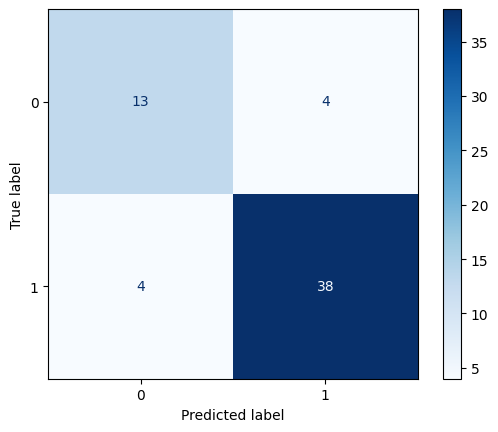

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Blues")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

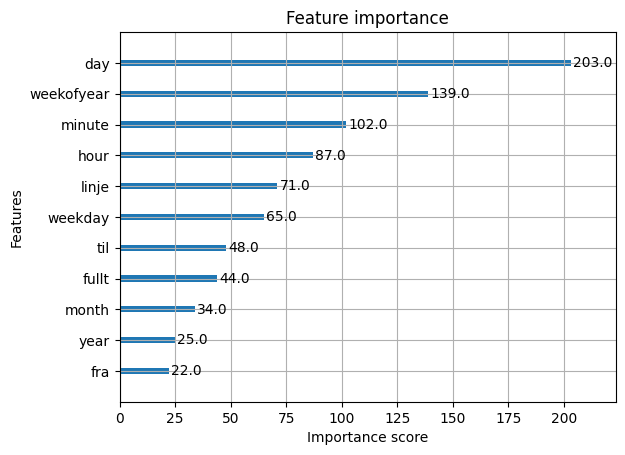

In [94]:
xgb.plot_importance(model)

## Model 2 - Model 1 with Optuna

In [95]:
import optuna as opt


def objective(trial):
    """The objective is to find the best parameters for the most accuracy in the model"""

    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'min_child_weight': trial.suggest_int('min_child_weight', 0, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1e+3),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.01, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        'eval_metric': 'mlogloss'
    }

    # Fit the model
    optuna_model = xgb.XGBClassifier(**params)
    optuna_model.fit(x_train, y_train)

    # Make predictions
    y_pred = optuna_model.predict(x_test)

    # Evaluate predictions
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy


study = opt.create_study(direction="maximize")
study.optimize(objective, n_trials=750)

[I 2025-09-12 21:33:20,954] A new study created in memory with name: no-name-d1cb2fef-72de-47f9-ab98-f289f580aa20
[I 2025-09-12 21:33:20,984] Trial 0 finished with value: 0.711864406779661 and parameters: {'max_depth': 3, 'learning_rate': 0.6852587652516119, 'n_estimators': 143, 'min_child_weight': 10, 'gamma': 884.8405202156121, 'subsample': 0.45185585265465034, 'colsample_bytree': 0.9666517737123236, 'reg_alpha': 0.03719084107741924, 'reg_lambda': 0.01740667922911256}. Best is trial 0 with value: 0.711864406779661.
[I 2025-09-12 21:33:21,042] Trial 1 finished with value: 0.711864406779661 and parameters: {'max_depth': 9, 'learning_rate': 0.89648244581504, 'n_estimators': 458, 'min_child_weight': 2, 'gamma': 707.4386315934287, 'subsample': 0.4468383930249007, 'colsample_bytree': 0.4127791925817051, 'reg_alpha': 0.429752760533694, 'reg_lambda': 0.8072089143689863}. Best is trial 0 with value: 0.711864406779661.
[I 2025-09-12 21:33:21,101] Trial 2 finished with value: 0.711864406779661 

In [96]:
bparams = study.best_params
model_2 = xgb.XGBClassifier(**bparams)
model_2.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3266826824441461
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [97]:
preds_2 = model_2.predict(x_test)

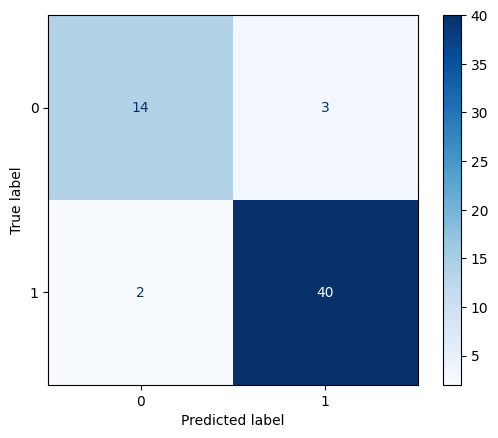

In [98]:
cm = confusion_matrix(y_true=y_test, y_pred=preds_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_2.classes_)

disp.plot(cmap='Blues')

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

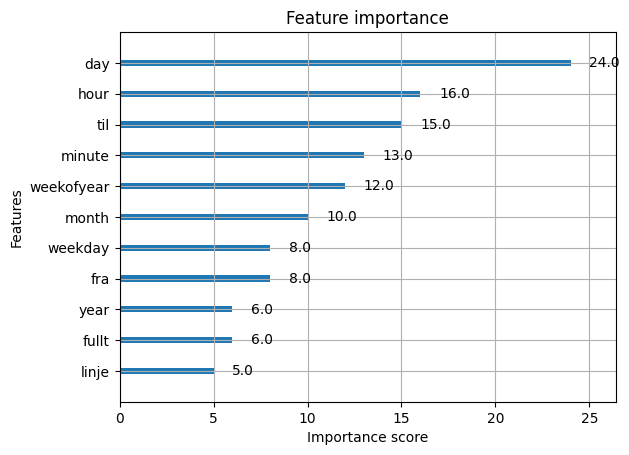

In [99]:
xgb.plot_importance(model_2)

In [100]:
accuracy_2 = accuracy_score(y_true=y_test, y_pred=preds_2)
print(f"Accuracy: {accuracy_2 * 100.0 :.2f}")

Accuracy: 91.53


# Save the best model

In [103]:
from datetime import UTC, datetime

# Model 2 will probably always be the best out of these two
model_2.save_model(f'../models/ticket-inspection-ai-model-{datetime.now(UTC).strftime("%Y%m%dT%H%M%S%z")}.pkl')

C:\Users\sigzu\miniconda3\envs\ticket-inspection-ai-2\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:40:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
